### First Data analytic Project

-> Problem statement : which physical feature affect selling price of a house, and make a genralized model to predict selling price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

# Data overview:
- We have 13 columns and 545 rows.
- 6 of them are numeric while 7 are categorical features.
- target is price of house.
- We have 3 types of furnishing_status houses.
- No null values.

# EDA

<Axes: xlabel='price', ylabel='Count'>

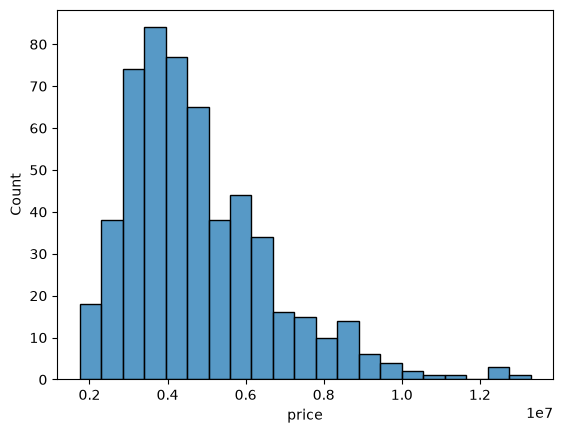

In [4]:
sns.histplot(data=df['price'])

##### The distribution of Price is right skewed as we can see in this graph which describe that we have more number of mid-range houses.

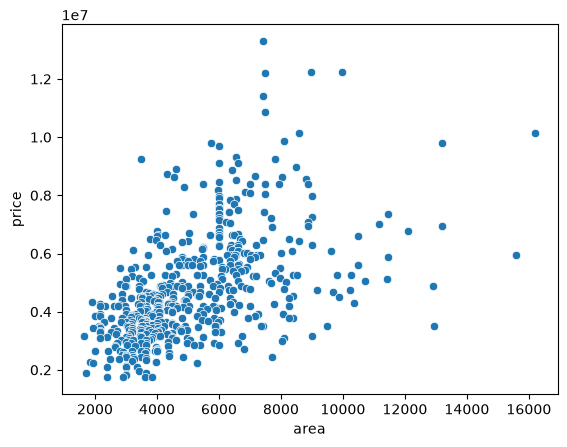

In [5]:
sns.scatterplot(data=df, x=df['area'], y=df['price'])
plt.show()

- the area vs price graph shows us that as area increases the price also increases, it also has an outlier. most of them range between 2000 sqft to 8000 sqft and the price range of 2M to 9M.

In [6]:
df['bathrooms'].value_counts(), df['bedrooms'].value_counts()

(bathrooms
 1    401
 2    133
 3     10
 4      1
 Name: count, dtype: int64,
 bedrooms
 3    300
 2    136
 4     95
 5     10
 6      2
 1      2
 Name: count, dtype: int64)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4064\4257865420.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bathrooms', y='price', data=avg_price, palette='magma')


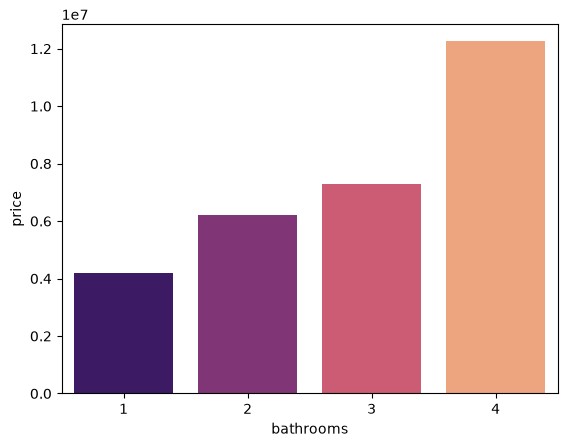

In [7]:
avg_price = df.groupby('bathrooms')['price'].mean().reset_index()
sns.barplot(x='bathrooms', y='price', data=avg_price, palette='magma')
plt.show()

- We can see the avg price increases as the numbers of bathrooms increases, a huge jump from avg of 3 bathrooms to 4 bathrooms house price 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4064\2010011724.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='bedrooms', y='price', data=avg_price, palette='plasma')


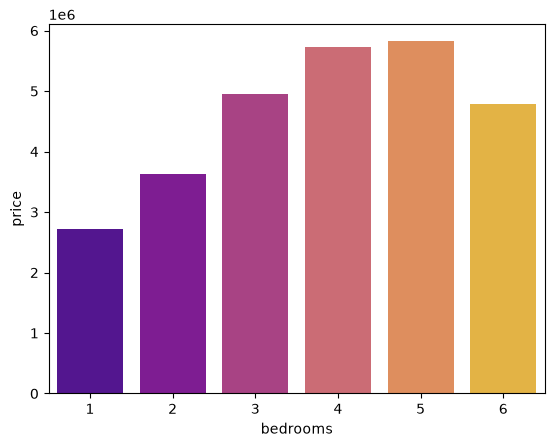

In [8]:
avg_price = df.groupby('bedrooms')['price'].mean().reset_index()
sns.barplot(x='bedrooms', y='price', data=avg_price, palette='plasma')
plt.show()

- the graph of avg price vs number of bedrooms shows the positive relation with target value as we increase no. of bedrooms price increases and there is also outlier there in dataset that's why the average price of 6 bedroom house is lower than the 5 bedroom house.

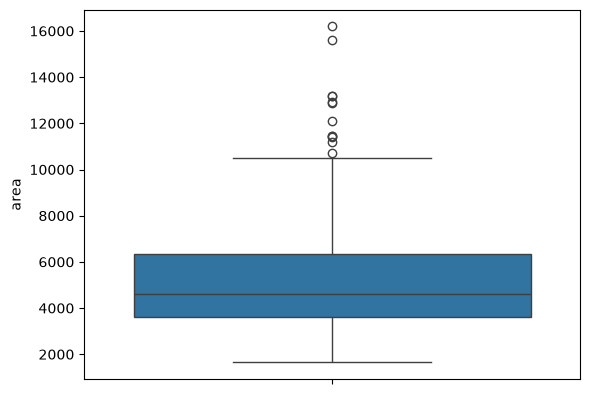

In [9]:
sns.boxplot(data=df['area'])
plt.show()


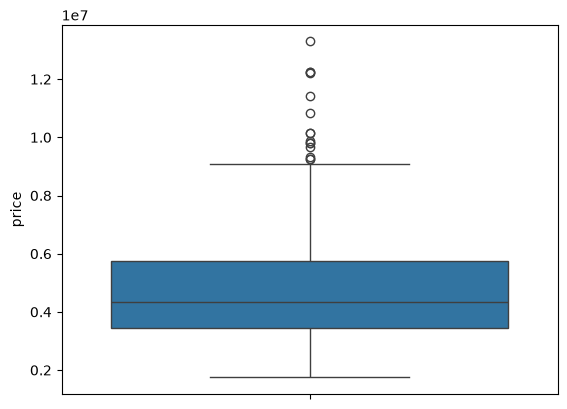

In [10]:
sns.boxplot(data=df['price'])
plt.show()

- It's clear from that dataset had outlier in price and area

### EDA insights
- Area has positive relation with target and can be a strong feature for prediction.
- the target value is right skewed from 2M to 8M with the mean of 4.25M.
- Bedrooms vs price also shows the postive relation between them.
- Same goes for the bathroom feature.
- bedroom and bathroom they both are related to the area and area is directly related to price, any of them increases area increases then price increase.
- from that we found that most of house have 3 best bedrooms and 1 bathroom in them.



### Preparing Data

In [11]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [12]:
df['price'].describe()

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
max      1.330000e+07
Name: price, dtype: float64

In [13]:
q1 = df['price'].quantile(0.25)
q2 = df['price'].quantile(0.75)
print(q1, q2)

3430000.0 5740000.0


In [14]:
iqr = q2 - q1
print(iqr)
lower = q1 - (1.5*iqr)
upper = q2 + (1.5*iqr)
print(lower, upper)
df.shape

2310000.0
-35000.0 9205000.0


(545, 13)

In [15]:
df = df[df['price'] < upper]
df.shape

(530, 13)

In [16]:
df


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,yes,no,yes,no,no,2,no,semi-furnished
16,9100000,6600,4,2,2,yes,yes,yes,no,yes,1,yes,unfurnished
17,8960000,8500,3,2,4,yes,no,no,no,yes,2,no,furnished
18,8890000,4600,3,2,2,yes,yes,no,no,yes,2,no,furnished
19,8855000,6420,3,2,2,yes,no,no,no,yes,1,yes,semi-furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


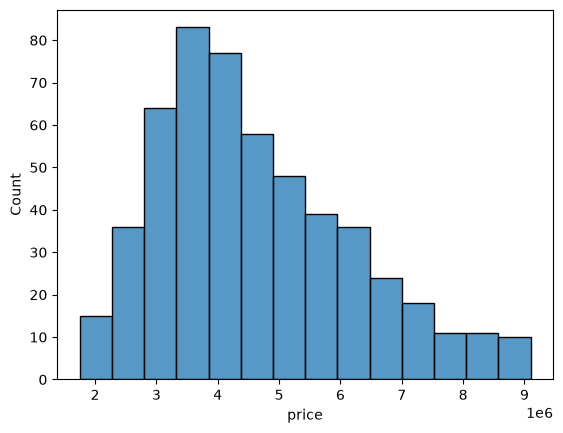

In [17]:
sns.histplot(data=df['price'])
plt.show()

In [18]:
df['area'].describe()

count      530.000000
mean      5061.518868
std       2075.449479
min       1650.000000
25%       3547.500000
50%       4500.000000
75%       6315.750000
max      15600.000000
Name: area, dtype: float64

In [19]:
aq1 = df['area'].quantile(0.25)
aq2 = df['area'].quantile(0.75)
print(aq1, aq2)
aiqr = aq2 - aq1
print(aiqr)


3547.5 6315.75
2768.25


In [20]:
alower = aq1-(1.5*aiqr)
aupper = aq2+(1.5*aiqr)
print(alower, aupper)
df.shape

-604.875 10468.125


(530, 13)

In [21]:
df = df[df['area']< aupper]
df.shape

(517, 13)

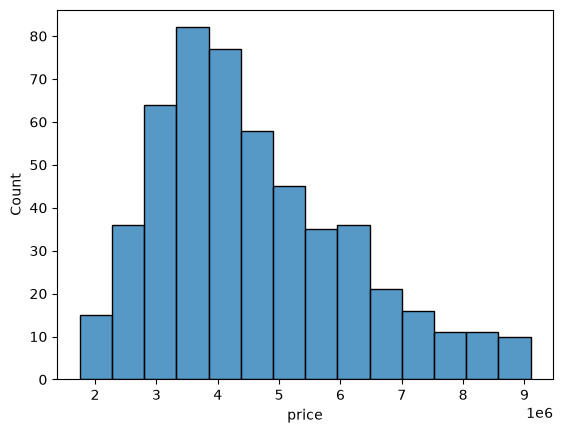

In [22]:
sns.histplot(data=df['price'])
plt.show()

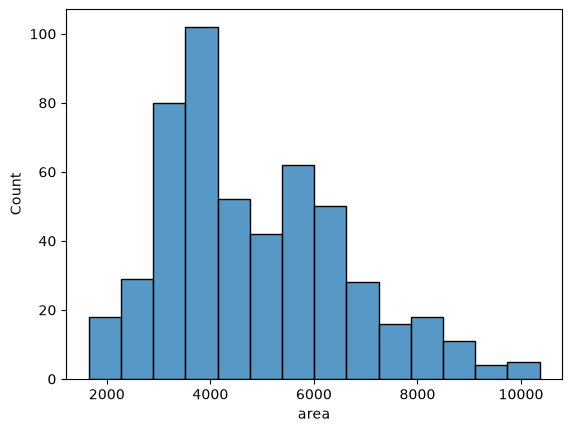

In [23]:
sns.histplot(data=df['area'])
plt.show()

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 517 entries, 15 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             517 non-null    int64
 1   area              517 non-null    int64
 2   bedrooms          517 non-null    int64
 3   bathrooms         517 non-null    int64
 4   stories           517 non-null    int64
 5   mainroad          517 non-null    str  
 6   guestroom         517 non-null    str  
 7   basement          517 non-null    str  
 8   hotwaterheating   517 non-null    str  
 9   airconditioning   517 non-null    str  
 10  parking           517 non-null    int64
 11  prefarea          517 non-null    str  
 12  furnishingstatus  517 non-null    str  
dtypes: int64(6), str(7)
memory usage: 56.5 KB


In [25]:
lst = ['guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'mainroad']

def fun(features):
    for feature in features:
        df[feature] = df[feature].map({'yes': 1, 'no': 0})
    return df

fun(lst)
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished


In [26]:
df['furnishingstatus'] = df['furnishingstatus'].map({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,2
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,2
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1


## Baseline model

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

In [28]:
target = df['price']
features = df.drop(columns='price')

In [29]:
X_train, X_test, y_train, y_test = train_test_split(features, target, random_state=42)

In [30]:
lr = LinearRegression()

lr.fit(X_train, y_train)

train_pred = lr.predict(X_train)
test_pred = lr.predict(X_test)

train_score = r2_score(y_train, train_pred)
test_score = r2_score(y_test, test_pred)

train_rmse = root_mean_squared_error(y_train, train_pred)
test_rmse = root_mean_squared_error(y_test, test_pred)

print("Train R²:", train_score)
print("Test R²:", test_score)


print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Train R²: 0.6516592674216274
Test R²: 0.6769765078624477
Train RMSE: 918031.9021850274
Test RMSE: 965432.1237881683


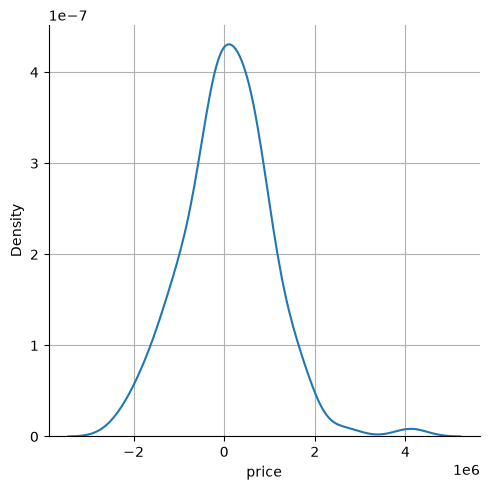

In [31]:
sns.displot(data=y_test-test_pred, kind='kde')
plt.grid()
plt.show()

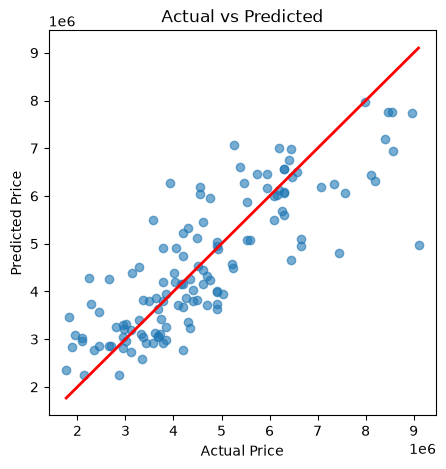

In [34]:
plt.figure(figsize=(5,5))
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red', lw=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

The model demonstrates a strong correlation between actual and predicted prices, indicating that it successfully captures the overall trend in the data. However, prediction errors increase slightly for higher-priced properties.

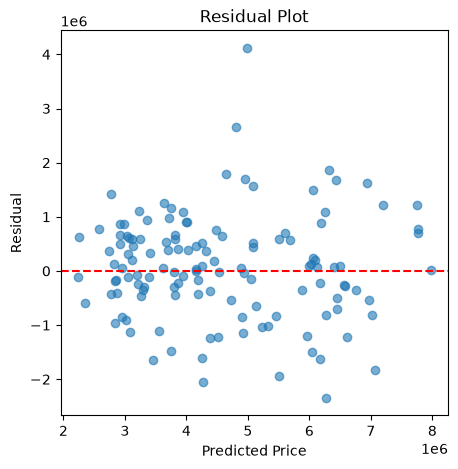

In [36]:
residuals = y_test - test_pred

plt.figure(figsize=(5,5))
plt.scatter(test_pred, residuals, alpha=0.6)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")
plt.show()

Residuals are randomly scattered around zero without a noticeable pattern, suggesting that the linear model adequately captures the relationship between the predictors and the target.

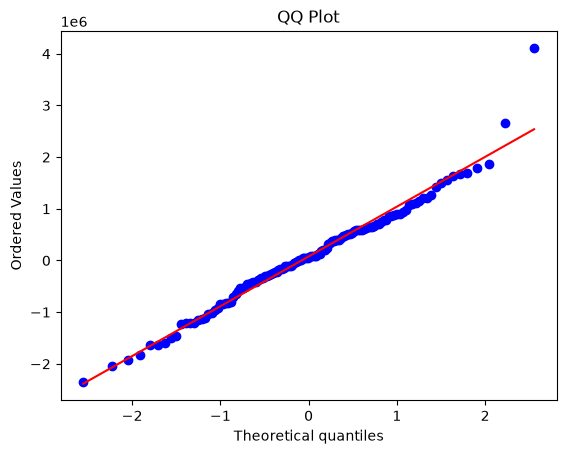

In [38]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)

plt.title("QQ Plot")
plt.show()


Residuals approximately follow a normal distribution, with minor deviations at the upper tail caused by a few outliers.

## 2nd Model testing

In [41]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

## Ridge Regression

In [44]:
params = {'alpha': [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100]}
rigde = Ridge()
rigdeCv = GridSearchCV(estimator=rigde, param_grid=params, cv=5)
ss = StandardScaler()

scaledX_train = ss.fit_transform(X_train)
scaledX_test = ss.transform(X_test)


rigdeCv.fit(scaledX_train, y_train)

r_trainpred = rigdeCv.predict(scaledX_train)
r_testpred = rigdeCv.predict(scaledX_test)

train_r2 = r2_score(y_train, r_trainpred)
test_r2 = r2_score(y_test, r_testpred)

train_Rmse = root_mean_squared_error(y_train, r_trainpred)
test_Rmse = root_mean_squared_error(y_test, r_testpred)

print("Train R²:", train_r2)
print("Test R²:", test_r2)


print("Train RMSE:", train_Rmse)
print("Test RMSE:", test_Rmse)


Train R²: 0.6489053647377818
Test R²: 0.674734883463834
Train RMSE: 921653.6339444043
Test RMSE: 968776.1447601141


## Lasso Regression

In [45]:
lasso = Lasso()
lassoCV = GridSearchCV(estimator=lasso, param_grid=params, cv=5)
ss = StandardScaler()

ScaledX_train = ss.fit_transform(X_train)
ScaledX_test = ss.transform(X_test)


lassoCV.fit(ScaledX_train, y_train)

l_trainpred = lassoCV.predict(ScaledX_train)
l_testpred = lassoCV.predict(ScaledX_test)

trainl_r2 = r2_score(y_train, r_trainpred)
testl_r2 = r2_score(y_test, r_testpred)

trainl_Rmse = root_mean_squared_error(y_train, l_trainpred)
testl_Rmse = root_mean_squared_error(y_test, l_testpred)

print("Train R²:", trainl_r2)
print("Test R²:", testl_r2)


print("Train RMSE:", trainl_Rmse)
print("Test RMSE:", testl_Rmse)

Train R²: 0.6489053647377818
Test R²: 0.674734883463834
Train RMSE: 918031.9361250163
Test RMSE: 965429.8982974172


## Elastic Net Regression

In [46]:
from sklearn.linear_model import ElasticNet
en = ElasticNet()
enCv = GridSearchCV(estimator=en, param_grid=params, cv=5)

enCv.fit(scaledX_train, y_train)


e_trainpred = enCv.predict(ScaledX_train)
e_testpred = enCv.predict(ScaledX_test)

trainE_r2 = r2_score(y_train, r_trainpred)
testE_r2 = r2_score(y_test, r_testpred)

trainE_Rmse = root_mean_squared_error(y_train, e_trainpred)
testE_Rmse = root_mean_squared_error(y_test, e_testpred)

print("Train R²:", trainE_r2)
print("Test R²:", testE_r2)


print("Train RMSE:", trainE_Rmse)
print("Test RMSE:", testE_Rmse)


Train R²: 0.6489053647377818
Test R²: 0.674734883463834
Train RMSE: 952360.2631007688
Test RMSE: 1001841.0760794856
